In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("cleaned_vaccinations.csv")
df['date'] = pd.to_datetime(df['date'])
df['daily_vaccinations_per_million'] = df.groupby('location')['daily_vaccinations_per_million'].transform(lambda x: x.fillna(x.mean()))

In [3]:
# --- Time Series Preparation ---
df_ts = df[df['location'] == 'India'].set_index('date')
ts_data = df_ts['daily_vaccinations_per_million'].asfreq('D')
ts_data.fillna(method='ffill', inplace=True)
ts_data = ts_data.dropna() # Drop any leading NaNs

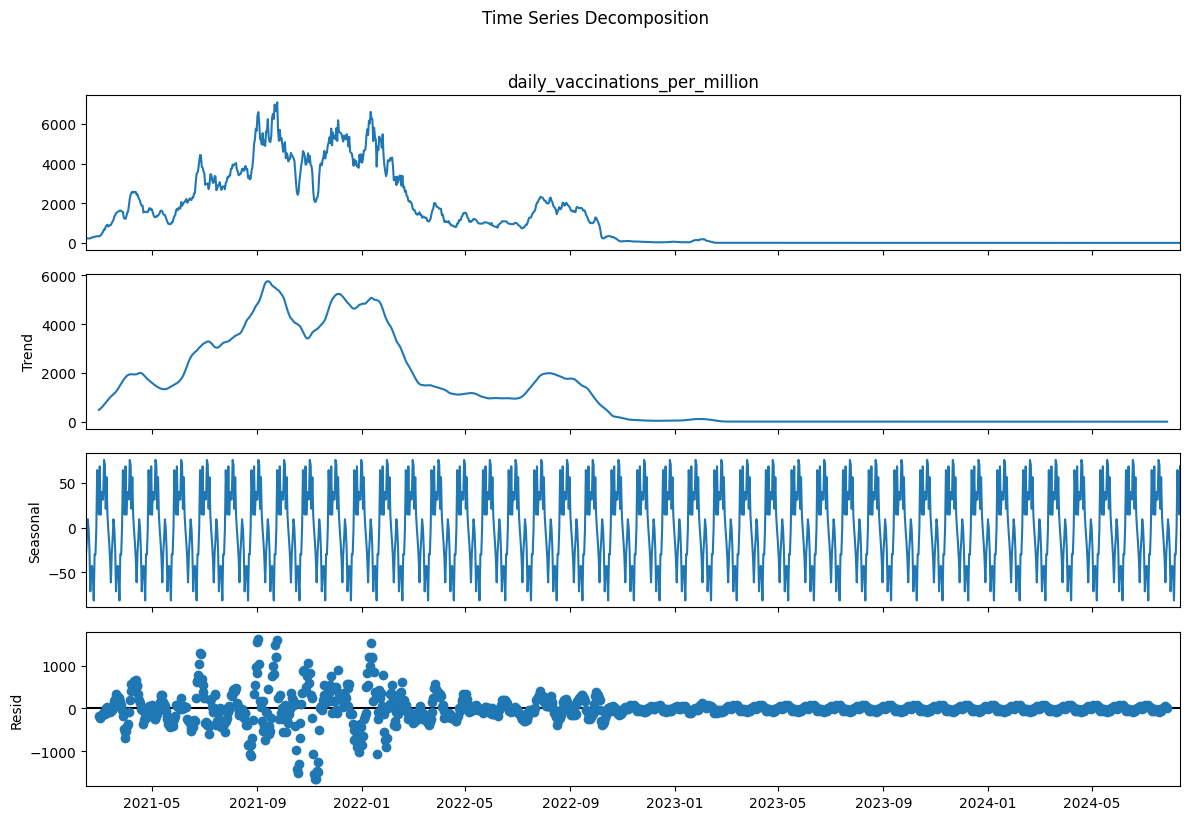

In [4]:
# --- Visualization 1: Time Series Decomposition ---
# We use a period of 30 for monthly patterns
decomposition = seasonal_decompose(ts_data, model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition', y=1.02)
plt.tight_layout()

In [5]:
# --- ARIMA Model Training and Forecasting ---
train_size = int(len(ts_data) * 0.8)
train, test = ts_data[0:train_size], ts_data[train_size:]

model_arima = ARIMA(train, order=(5, 1, 0))
model_fit = model_arima.fit()
    
print("\nARIMA Model Summary:")
print(model_fit.summary())

predictions = model_fit.forecast(steps=len(test))


ARIMA Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:     daily_vaccinations_per_million   No. Observations:                 1021
Model:                             ARIMA(5, 1, 0)   Log Likelihood               -6828.758
Date:                            Mon, 13 Oct 2025   AIC                          13669.515
Time:                                    11:08:36   BIC                          13699.081
Sample:                                02-13-2021   HQIC                         13680.741
                                     - 11-30-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0820      0.014     -5.698      0.000      -0.110      -0.054
ar.L2        


ARIMA Test RMSE: 0.91
Saved forecast plot to 'india_vaccination_forecast.png'


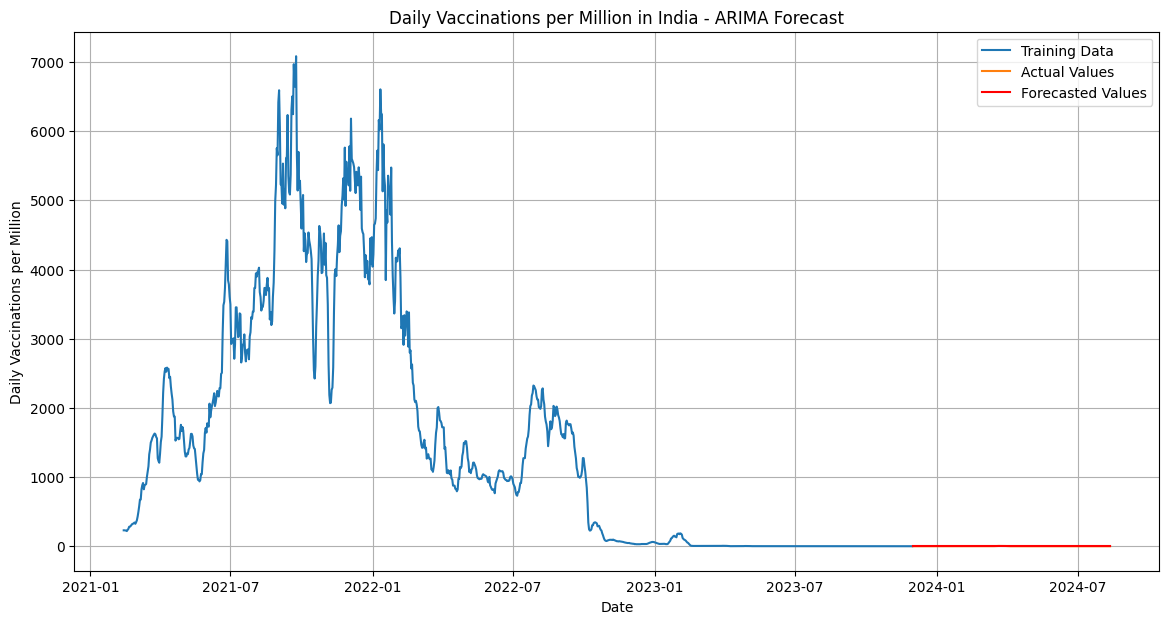

In [ ]:
# --- Evaluation and Visualization 2: Forecast Plot ---
error = np.sqrt(mean_squared_error(test, predictions))
print(f'\nARIMA Test RMSE: {error:.2f}')
plt.figure(figsize=(14, 7))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Values')
plt.plot(test.index, predictions, label='Forecasted Values', color='red')
plt.title('Daily Vaccinations per Million in India - ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Daily Vaccinations per Million')
plt.legend()
plt.grid(True)